# Feature Searching

In this notebook we focus on attempting to find features between sets of maps.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import map_fun as mf
import msgspec
import plot_fun as pf

mf.maps_path = "/global/u2/a/andrs/Products/Mars/i1/"
mf.maps_dict = "/global/u2/a/andrs/Products/Mars/i1/maps.json"

maps= mf.load_maps(wafer='*', band='*', clean_only=True, blacklist=[
    'obs_1759346027_lati1_111',
    'obs_1757710644_lati1_111',
    'obs_1758726252_lati1_111',
    'obs_1759605678_lati1_111',
    'obs_1759004851_lati1_111',
    'obs_1747177373_lati1_111',
    'obs_1750464250_lati1_111',
    'obs_1756222499_lati1_111'
])

with open(mf.maps_dict, "rb") as f:
    encoded = f.read()

maps_meta = msgspec.json.decode(encoded)

In [2]:
import warnings
warnings.filterwarnings('ignore')

y, x = np.mgrid[0:180, 0:180]
coords = (y, x)
dist = np.sqrt((x - 90)**2 + (y - 90)**2)
mask_f090 = dist <= 30
mask_f150 = dist <= 25
zoom = (60, 120, 60, 120)

## Zernike Modes Comparisions

### Prepare Data

In [3]:
stacked_f90al1 = mf.stack_maps([x for x in maps if x.band == "f090" and x.season_class == 'first_alignment'], stackres=True)
stacked_f90al2 = mf.stack_maps([x for x in maps if x.band == 'f090' and x.season_class== 'second_alignment'], stackres=True)
stacked_f150al1 = mf.stack_maps([x for x in maps if x.band == 'f150' and x.season_class== 'first_alignment'],  stackres=True)
stacked_f150al2 = mf.stack_maps([x for x in maps if x.band == 'f150' and x.season_class== 'second_alignment'], stackres=True)

In [37]:
from tqdm.notebook import tqdm

data = [x for x in maps if x.season_class == 'second_alignment' and x.band == 'f150']
coefficients = []
reconstructions = []

for map2use in tqdm(data):
    T = map2use.solved[0]
    W = map2use.weights[0][0]
    mux, muy= map2use.EllipticGaussian.mux[0], map2use.EllipticGaussian.muy[0]
    ny,nx = T.shape
    y, x = np.mgrid[0:ny, 0:nx]
    coords = (y, x)
    
    model = EllipticGaussian()
    popt = map2use.EllipticGaussian.get_popt()
    fit = model.func((y, x), *popt).reshape((180,180))
    residual = T - fit
    residual -= map2use.EllipticGaussian.offset[0]
    residual /= map2use.EllipticGaussian.amp[0]
    
    r = np.sqrt((x - mux)**2 + (y - muy)**2)
    theta = np.arctan2(y - muy, x - mux)
    radius = 30
    mask = r <= radius
    r_max = np.max(r[mask])
    r_norm = r / r_max 
    res_masked = residual*mask
    
    coeffs = zernike_decompose(residual, r_norm, theta, mask, nmax=30)
    
    reconstructed = np.zeros_like(residual)
    for n, m, a in coeffs:
        reconstructed += a * zernike(n, m, r_norm, theta) * mask
    coefficients.append(coeffs)
    reconstructions.append(reconstructed)

  0%|          | 0/15 [00:00<?, ?it/s]

In [38]:
np.save('f150al2_coeffs.npy', coefficients)

In [5]:
f90al1_coeffs = np.load('saved_arrays/f90al1_coeffs.npy')
f90al2_coeffs = np.load('saved_arrays/f90al2_coeffs.npy')
f150al1_coeffs = np.load('saved_arrays/f150al1_coeffs.npy')
f150al2_coeffs = np.load('saved_arrays/f150al2_coeffs.npy')

### Heatmap

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

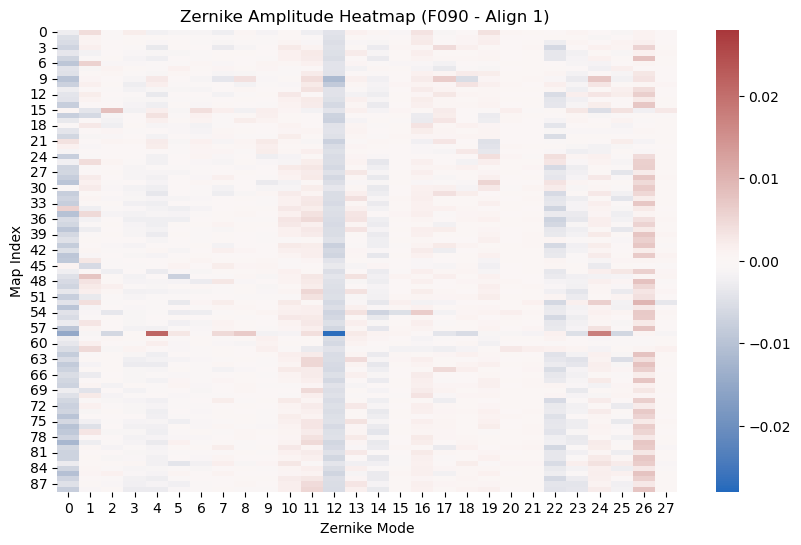

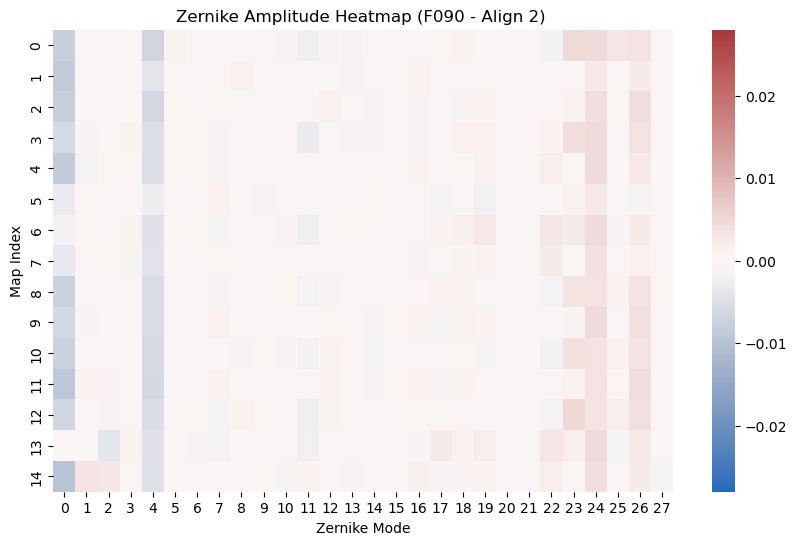

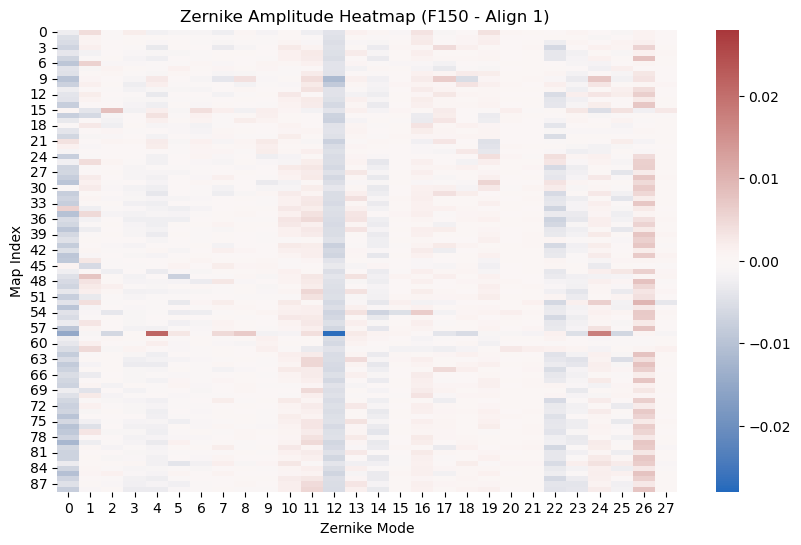

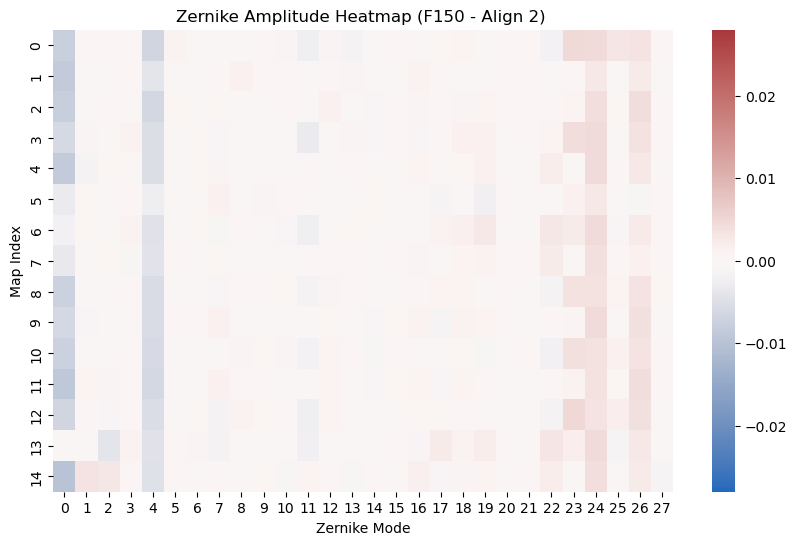

In [7]:
vmax, vmin = 0.028, -0.028
zernike_amplitudes = f90al1_coeffs[:, :28, 2]
n_maps, n_modes = zernike_amplitudes.shape
plt.figure(figsize=(10, 6))
sns.heatmap(zernike_amplitudes, cmap='vlag', vmin=vmin, vmax=vmax)
plt.xlabel("Zernike Mode")
plt.ylabel("Map Index")
plt.title(f"Zernike Amplitude Heatmap (F090 - Align 1) ")
plt.show()

vmax, vmin = 0.028, -0.028
zernike_amplitudes = f150al2_coeffs[:, :28, 2]
n_maps, n_modes = zernike_amplitudes.shape
plt.figure(figsize=(10, 6))
sns.heatmap(zernike_amplitudes, cmap='vlag', vmin=vmin, vmax=vmax)
plt.xlabel("Zernike Mode")
plt.ylabel("Map Index")
plt.title(f"Zernike Amplitude Heatmap (F090 - Align 2) ")
plt.show()

vmax, vmin = 0.028, -0.028
zernike_amplitudes = f90al1_coeffs[:, :28, 2]
n_maps, n_modes = zernike_amplitudes.shape
plt.figure(figsize=(10, 6))
sns.heatmap(zernike_amplitudes, cmap='vlag', vmin=vmin, vmax=vmax)
plt.xlabel("Zernike Mode")
plt.ylabel("Map Index")
plt.title(f"Zernike Amplitude Heatmap (F150 - Align 1) ")
plt.show()

vmax, vmin = 0.028, -0.028
zernike_amplitudes = f150al2_coeffs[:, :28, 2]
n_maps, n_modes = zernike_amplitudes.shape
plt.figure(figsize=(10, 6))
sns.heatmap(zernike_amplitudes, cmap='vlag', vmin=vmin, vmax=vmax)
plt.xlabel("Zernike Mode")
plt.ylabel("Map Index")
plt.title(f"Zernike Amplitude Heatmap (F150 - Align 2) ")
plt.show()

### PCA

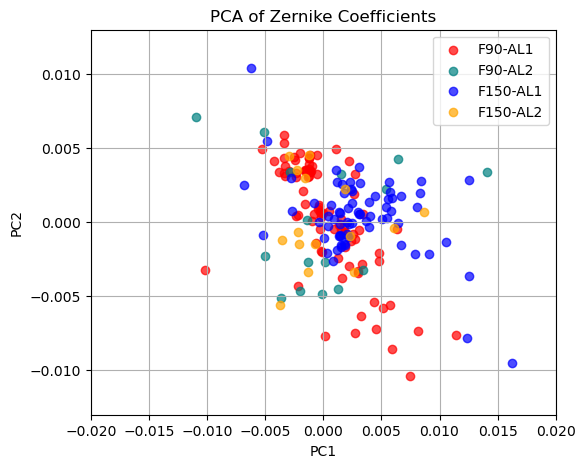

In [8]:
pca = PCA(n_components=2)
proj_pca1 = pca.fit_transform(f90al1_coeffs[:, :28, 2])
proj_pca2 = pca.fit_transform(f90al2_coeffs[:, :28, 2])
proj_pca3 = pca.fit_transform(f150al1_coeffs[:, :28, 2])
proj_pca4 = pca.fit_transform(f150al2_coeffs[:, :28, 2])


plt.figure(figsize=(6,5))
plt.scatter(proj_pca1[:,0], proj_pca1[:,1], c='red', alpha=0.7, label='F90-AL1')
plt.scatter(proj_pca2[:,0], proj_pca2[:,1], c='teal', alpha=0.7, label='F90-AL2')
plt.scatter(proj_pca3[:,0], proj_pca3[:,1], c='blue', alpha=0.7, label='F150-AL1')
plt.scatter(proj_pca4[:,0], proj_pca4[:,1], c='orange', alpha=0.7, label='F150-AL2')

plt.title("PCA of Zernike Coefficients")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.xlim(-0.02, 0.02)
plt.ylim(-0.013, 0.013)

plt.grid(True)
plt.show()


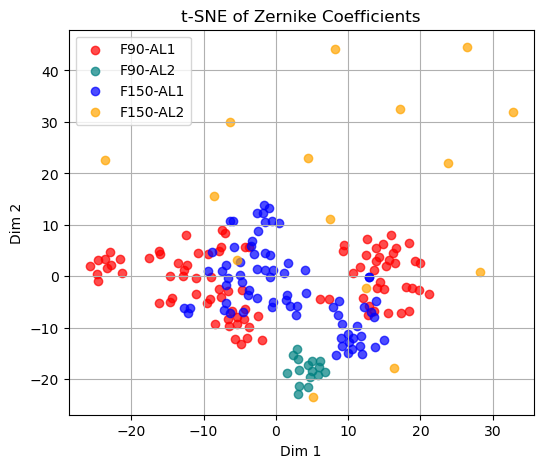

In [9]:
tsne = TSNE(n_components=2, perplexity=10, random_state=0)
proj_tsne1 = tsne.fit_transform(f90al1_coeffs[:, :28, 2])
proj_tsne2 = tsne.fit_transform(f90al2_coeffs[:, :28, 2])
proj_tsne3 = tsne.fit_transform(f150al1_coeffs[:, :28, 2])
proj_tsne4 = tsne.fit_transform(f150al2_coeffs[:, :28, 2])


plt.figure(figsize=(6,5))
plt.scatter(proj_tsne1[:,0], proj_tsne1[:,1], c='red', alpha=0.7, label='F90-AL1')
plt.scatter(proj_tsne2[:,0], proj_tsne2[:,1], c='teal', alpha=0.7, label='F90-AL2')
plt.scatter(proj_tsne3[:,0], proj_tsne3[:,1], c='blue', alpha=0.7, label='F150-AL1')
plt.scatter(proj_tsne4[:,0], proj_tsne4[:,1], c='orange', alpha=0.7, label='F150-AL2')

plt.title("t-SNE of Zernike Coefficients")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.legend()
plt.show()


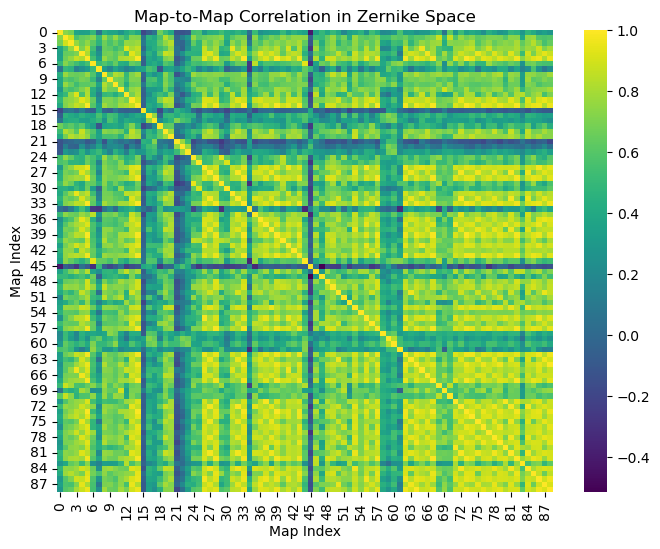

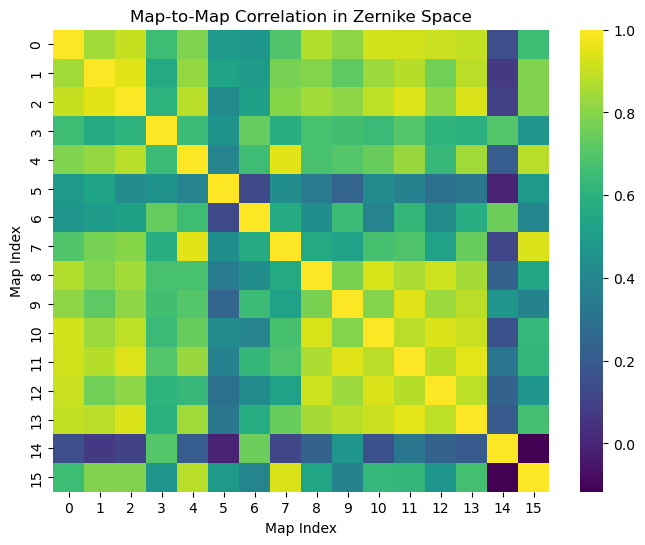

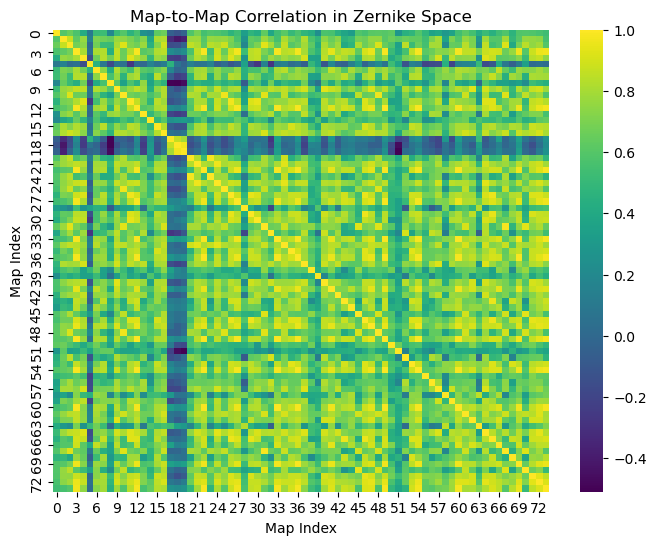

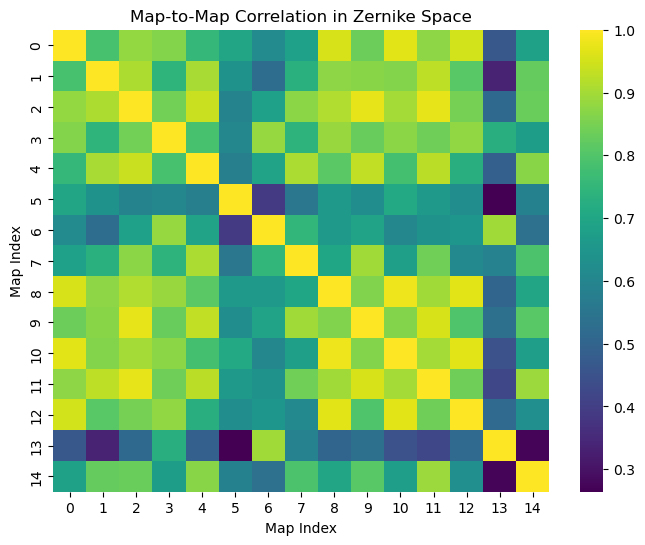

In [10]:
corr = np.corrcoef(f90al1_coeffs[:, :28, 2])
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='viridis')
plt.title("Map-to-Map Correlation in Zernike Space")
plt.xlabel("Map Index")
plt.ylabel("Map Index")
plt.show()

corr = np.corrcoef(f90al2_coeffs[:, :28, 2])
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='viridis')
plt.title("Map-to-Map Correlation in Zernike Space")
plt.xlabel("Map Index")
plt.ylabel("Map Index")
plt.show()


corr = np.corrcoef(f150al1_coeffs[:, :28, 2])
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='viridis')
plt.title("Map-to-Map Correlation in Zernike Space")
plt.xlabel("Map Index")
plt.ylabel("Map Index")
plt.show()


corr = np.corrcoef(f150al2_coeffs[:, :28, 2])
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='viridis')
plt.title("Map-to-Map Correlation in Zernike Space")
plt.xlabel("Map Index")
plt.ylabel("Map Index")
plt.show()

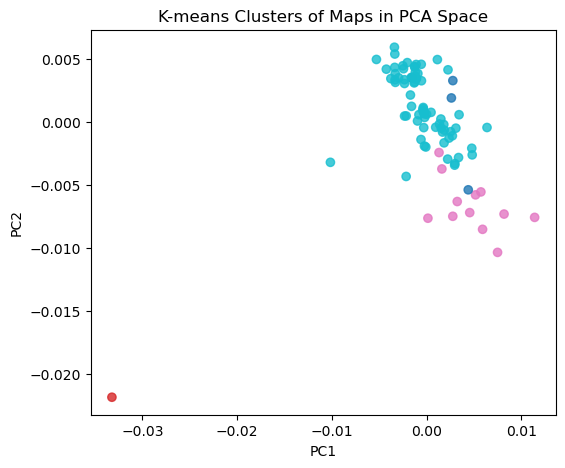

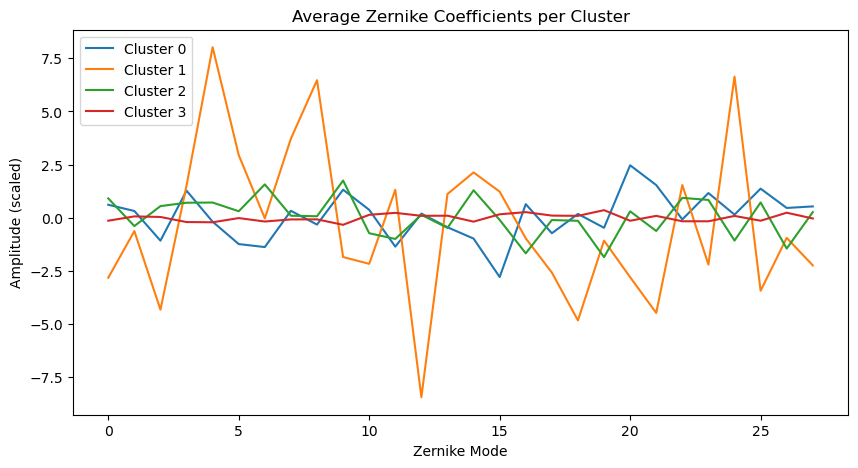

In [11]:
scaler = StandardScaler()
scaled = scaler.fit_transform(f90al1_coeffs[:, :28, 2])

kmeans = KMeans(n_clusters=4, random_state=0)
labels = kmeans.fit_predict(scaled)

plt.figure(figsize=(6,5))
plt.scatter(proj_pca1[:,0], proj_pca1[:,1], c=labels, cmap='tab10', alpha=0.8)
plt.title("K-means Clusters of Maps in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Plot average Zernike pattern per cluster
plt.figure(figsize=(10,5))
for c in range(4):
    plt.plot(kmeans.cluster_centers_[c], label=f'Cluster {c}')
plt.title("Average Zernike Coefficients per Cluster")
plt.xlabel("Zernike Mode")
plt.ylabel("Amplitude (scaled)")
plt.legend()
plt.show()